# Customer Data ETL & Analytics Pipeline
# Technology: Python, Pandas, SQLite, SQL
# Author: Sakshi Mishra

## Project Overview

This project demonstrates an end-to-end ETL pipeline for customer and transaction data.

The pipeline performs:

- Data ingestion from CSV and JSON sources
- Data profiling and quality checks
- Data cleaning and transformation using Python and Pandas
- Relational data storage using SQLite
- SQL-based analytics
- Customer, product, category and revenue analysis
- Data visualization

## Architecture

CSV / JSON
→ Python & Pandas
→ Data Validation
→ Data Transformation
→ SQLite Database
→ SQL Analytics
→ Business Insights

In [110]:
print("Customer Data ETL & Analytics Pipeline")
print("=" * 50)

Customer Data ETL & Analytics Pipeline


## 1. ETL Pipeline

### Extract
Read customer data from CSV and order data from JSON.

### Transform
- Remove duplicate records
- Handle missing values
- Validate dates
- Validate quantities and prices
- Calculate total transaction amount

### Load
Load the cleaned datasets into relational SQLite tables.

### Analyze
Use SQL queries to generate customer, product, category and revenue insights.

In [111]:
import pandas as pd
import numpy as np
import json
import sqlite3
import os
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


#**Raw Dataset**

In [112]:
customers = pd.DataFrame({
    "customer_id": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                    11, 12, 13, 14, 15],

    "name": [
        "Aarav", "Priya", "Rahul", "Ananya", "Rohan",
        "Sneha", "Aditya", "Isha", "Karan", "Neha",
        "Arjun", "Simran", "Varun", "Meera", "Kabir"
    ],

    "email": [
        "aarav@gmail.com",
        "priya@gmail.com",
        "rahul@gmail.com",
        None,
        "rohan@gmail.com",
        "sneha@gmail.com",
        "aditya@gmail.com",
        "isha@gmail.com",
        "karan@gmail.com",
        "neha@gmail.com",
        "arjun@gmail.com",
        "simran@gmail.com",
        "varun@gmail.com",
        "meera@gmail.com",
        "kabir@gmail.com"
    ],

    "city": [
        "Delhi", "Mumbai", "Bangalore", "Delhi", "Pune",
        "Hyderabad", None, "Delhi", "Mumbai", "Noida",
        "Delhi", "Pune", "Chennai", "Delhi", "Mumbai"
    ],

    "signup_date": [
        "2025-01-10", "2025-01-15", "2025-02-01",
        "2025-02-10", "2025-02-20", "2025-03-05",
        "2025-03-10", "2025-03-15", "2025-04-01",
        "2025-04-10", "2025-04-15", "2025-05-01",
        "2025-05-10", "2025-05-20", "2025-06-01"
    ]
})


customers = pd.concat(
    [customers, customers.iloc[[4]]],
    ignore_index=True
)

customers

,customer_id,name,email,city,signup_date
0,1,Aarav,aarav@gmail.com,Delhi,2025-01-10
1,2,Priya,priya@gmail.com,Mumbai,2025-01-15
2,3,Rahul,rahul@gmail.com,Bangalore,2025-02-01
3,4,Ananya,None,Delhi,2025-02-10
4,5,Rohan,rohan@gmail.com,Pune,2025-02-20
5,6,Sneha,sneha@gmail.com,Hyderabad,2025-03-05
6,7,Aditya,aditya@gmail.com,None,2025-03-10
7,8,Isha,isha@gmail.com,Delhi,2025-03-15
8,9,Karan,karan@gmail.com,Mumbai,2025-04-01
9,10,Neha,neha@gmail.com,Noida,2025-04-10


In [113]:
customers.to_csv(
    "customers_raw.csv",
    index=False
)

print("Customer CSV file created successfully.")

Customer CSV file created successfully.


In [114]:
orders.to_json(
    "orders_raw.json",
    orient="records",
    indent=4
)

print("Order JSON file created successfully.")

Order JSON file created successfully.


# **1 Extract**

The raw customer data is stored in CSV format and order data is stored in JSON format.

The pipeline reads both files using Python and Pandas before beginning the transformation process.

In [115]:
customers_raw = pd.read_csv("customers_raw.csv")


orders_raw = pd.read_json("orders_raw.json")

print("Customer records extracted:", len(customers_raw))
print("Order records extracted:", len(orders_raw))

Customer records extracted: 16
Order records extracted: 20


In [116]:
customers = customers_raw.copy()
orders = orders_raw.copy()

**Inspect the raw data**

In [117]:
print("Dataset Shape:", customers.shape)
print("\nColumn Information:")
print(customers.info())

Dataset Shape: (16, 5)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  16 non-null     int64 
 1   name         16 non-null     object
 2   email        15 non-null     object
 3   city         15 non-null     object
 4   signup_date  16 non-null     object
dtypes: int64(1), object(4)
memory usage: 772.0+ bytes
None


In [118]:
print("Missing Values:")
print(customers.isnull().sum())

Missing Values:
customer_id    0
name           0
email          1
city           1
signup_date    0
dtype: int64


In [119]:
print("Duplicate Customer IDs:")
print(customers["customer_id"].duplicated().sum())

Duplicate Customer IDs:
1


In [145]:
# Introduce intentional data-quality problems
orders_raw.loc[5, "quantity"] = -1
orders_raw.loc[10, "unit_price"] = -500

orders = orders_raw.copy()

orders

,order_id,customer_id,order_date,product,category,quantity,unit_price
0,101,1,2025-06-01,Laptop,Electronics,1,55000
1,102,2,2025-06-03,Phone,Electronics,2,25000
2,103,3,2025-06-05,Headphones,Electronics,1,3000
3,104,4,2025-06-07,Shoes,Fashion,2,2500
4,105,5,2025-06-10,Laptop,Electronics,1,60000
5,106,6,2025-06-12,Watch,Fashion,-1,5000
6,107,7,2025-06-15,Phone,Electronics,2,22000
7,108,8,2025-06-18,Keyboard,Electronics,1,4000
8,109,9,2025-06-20,Shoes,Fashion,3,3000
9,110,10,2025-06-22,Mouse,Electronics,2,1500


#**Clean the customers data**

1.   Removing duplicate customers
2.   Handling missing email
3.   Handling missing city
4.   signup date conversion





In [122]:
customers_clean = customers.copy()


customers_clean = customers_clean.drop_duplicates(
    subset=["customer_id"]
)


customers_clean["email"] = customers_clean["email"].fillna(
    "unknown@example.com"
)


customers_clean["city"] = customers_clean["city"].fillna(
    "Unknown"
)


customers_clean["signup_date"] = pd.to_datetime(
    customers_clean["signup_date"],
    errors="coerce"
)

print("Customer records before cleaning:", len(customers))
print("Customer records after cleaning:", len(customers_clean))

customers_clean

Customer records before cleaning: 16
Customer records after cleaning: 15


,customer_id,name,email,city,signup_date
0,1,Aarav,aarav@gmail.com,Delhi,2025-01-10
1,2,Priya,priya@gmail.com,Mumbai,2025-01-15
2,3,Rahul,rahul@gmail.com,Bangalore,2025-02-01
3,4,Ananya,unknown@example.com,Delhi,2025-02-10
4,5,Rohan,rohan@gmail.com,Pune,2025-02-20
5,6,Sneha,sneha@gmail.com,Hyderabad,2025-03-05
6,7,Aditya,aditya@gmail.com,Unknown,2025-03-10
7,8,Isha,isha@gmail.com,Delhi,2025-03-15
8,9,Karan,karan@gmail.com,Mumbai,2025-04-01
9,10,Neha,neha@gmail.com,Noida,2025-04-10


#**Clean the order data**


1.   Convert numeric columns

1.   Convert date

1.   Remove invalid quantity
2.   Remove invalid price


2.   Calculate total order value




In [123]:
orders_clean = orders.copy()

orders_clean["quantity"] = pd.to_numeric(
    orders_clean["quantity"],
    errors="coerce"
)

orders_clean["unit_price"] = pd.to_numeric(
    orders_clean["unit_price"],
    errors="coerce"
)


orders_clean["order_date"] = pd.to_datetime(
    orders_clean["order_date"],
    errors="coerce"
)


orders_clean = orders_clean[
    orders_clean["quantity"] > 0
]

orders_clean = orders_clean[
    orders_clean["unit_price"] > 0
]


orders_clean["total_amount"] = (
    orders_clean["quantity"] *
    orders_clean["unit_price"]
)

orders_clean

,order_id,customer_id,order_date,product,category,quantity,unit_price,total_amount
0,101,1,2025-06-01,Laptop,Electronics,1,55000,55000
1,102,2,2025-06-03,Phone,Electronics,2,25000,50000
2,103,3,2025-06-05,Headphones,Electronics,1,3000,3000
3,104,4,2025-06-07,Shoes,Fashion,2,2500,5000
4,105,5,2025-06-10,Laptop,Electronics,1,60000,60000
6,107,7,2025-06-15,Phone,Electronics,2,22000,44000
7,108,8,2025-06-18,Keyboard,Electronics,1,4000,4000
8,109,9,2025-06-20,Shoes,Fashion,3,3000,9000
9,110,10,2025-06-22,Mouse,Electronics,2,1500,3000
11,112,3,2025-07-03,Phone,Electronics,1,28000,28000


#**Create a Data Quality Report**

In [124]:
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

print("\nCUSTOMERS")
print("Raw records:", len(customers))
print("Clean records:", len(customers_clean))
print("Duplicates removed:",
      len(customers) - len(customers_clean))

print("\nORDERS")
print("Raw records:", len(orders))
print("Clean records:", len(orders_clean))
print("Invalid records removed:",
      len(orders) - len(orders_clean))

print("\nMissing values after cleaning:")
print(customers_clean.isnull().sum())

print("\nTotal Revenue:")
print(
    round(orders_clean["total_amount"].sum(), 2)
)

DATA QUALITY REPORT

CUSTOMERS
Raw records: 16
Clean records: 15
Duplicates removed: 1

ORDERS
Raw records: 20
Clean records: 18
Invalid records removed: 2

Missing values after cleaning:
customer_id    0
name           0
email          0
city           0
signup_date    0
dtype: int64

Total Revenue:
405000


#2. Data Model

The project uses two relational tables:

### Customers

| Column | Description |
|---|---|
| customer_id | Unique customer identifier |
| name | Customer name |
| email | Customer email |
| city | Customer city |
| signup_date | Customer registration date |

### Orders

| Column | Description |
|---|---|
| order_id | Unique order identifier |
| customer_id | Customer reference |
| order_date | Date of order |
| product | Purchased product |
| category | Product category |
| quantity | Quantity purchased |
| unit_price | Price per unit |
| total_amount | Quantity × unit price |


### Relationships

- `customers.customer_id` — Primary Key
- `orders.order_id` — Primary Key
- `orders.customer_id` — Foreign Key

### Relationship

`customers.customer_id` → `orders.customer_id`

One customer can have multiple orders.

#3. **SQL analytics**

In [125]:
import sqlite3


connection = sqlite3.connect("customer_pipeline.db")

print("SQLite database created successfully!")

SQLite database created successfully!


In [126]:
customers_clean.to_sql(
    "customers",
    connection,
    if_exists="replace",
    index=False
)


orders_clean.to_sql(
    "orders",
    connection,
    if_exists="replace",
    index=False
)

print("Customers table loaded:", len(customers_clean))
print("Orders table loaded:", len(orders_clean))

Customers table loaded: 15
Orders table loaded: 18


In [127]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    connection
)

tables

,name
0,customers
1,orders


In [128]:
pd.read_sql_query(
    "SELECT * FROM customers LIMIT 5;",
    connection
)

,customer_id,name,email,city,signup_date
0,1,Aarav,aarav@gmail.com,Delhi,2025-01-10 00:00:00
1,2,Priya,priya@gmail.com,Mumbai,2025-01-15 00:00:00
2,3,Rahul,rahul@gmail.com,Bangalore,2025-02-01 00:00:00
3,4,Ananya,unknown@example.com,Delhi,2025-02-10 00:00:00
4,5,Rohan,rohan@gmail.com,Pune,2025-02-20 00:00:00


In [129]:
pd.read_sql_query(
    "SELECT * FROM orders LIMIT 5;",
    connection
)

,order_id,customer_id,order_date,product,category,quantity,unit_price,total_amount
0,101,1,2025-06-01 00:00:00,Laptop,Electronics,1,55000,55000
1,102,2,2025-06-03 00:00:00,Phone,Electronics,2,25000,50000
2,103,3,2025-06-05 00:00:00,Headphones,Electronics,1,3000,3000
3,104,4,2025-06-07 00:00:00,Shoes,Fashion,2,2500,5000
4,105,5,2025-06-10 00:00:00,Laptop,Electronics,1,60000,60000


**3.1 Total Revenue**

In [130]:
query = """
SELECT
    ROUND(SUM(total_amount), 2) AS total_revenue
FROM orders;
"""

result = pd.read_sql_query(query, connection)

result

,total_revenue
0,405000.0


**3.2 Revenue by Category**

In [131]:
query = """
SELECT
    category,
    ROUND(SUM(total_amount), 2) AS revenue
FROM orders
GROUP BY category
ORDER BY revenue DESC;
"""

category_revenue = pd.read_sql_query(
    query,
    connection
)

category_revenue

,category,revenue
0,Electronics,370400.0
1,Fashion,34600.0


**3.3 Revenue by City using JOIN**

In [132]:
query = """
SELECT
    c.city,
    ROUND(SUM(o.total_amount), 2) AS revenue
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
GROUP BY c.city
ORDER BY revenue DESC;
"""

city_revenue = pd.read_sql_query(
    query,
    connection
)

city_revenue

,city,revenue
0,Delhi,126500.0
1,Pune,74400.0
2,Mumbai,70600.0
3,Chennai,52000.0
4,Unknown,47500.0
5,Bangalore,31000.0
6,Noida,3000.0


**3.4 Top Customers**

In [133]:
query = """
SELECT
    c.customer_id,
    c.name,
    c.city,
    ROUND(SUM(o.total_amount), 2) AS total_spending
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
GROUP BY
    c.customer_id,
    c.name,
    c.city
ORDER BY total_spending DESC
LIMIT 10;
"""

top_customers = pd.read_sql_query(
    query,
    connection
)

top_customers

,customer_id,name,city,total_spending
0,5,Rohan,Pune,69000.0
1,11,Arjun,Delhi,58000.0
2,1,Aarav,Delhi,55000.0
3,13,Varun,Chennai,52000.0
4,2,Priya,Mumbai,50000.0
5,7,Aditya,Unknown,47500.0
6,3,Rahul,Bangalore,31000.0
7,9,Karan,Mumbai,14600.0
8,15,Kabir,Mumbai,6000.0
9,12,Simran,Pune,5400.0


**3.5 Customer Spending -CTE**

In [134]:
query = """
WITH customer_sales AS (

    SELECT
        customer_id,
        SUM(total_amount) AS total_spending
    FROM orders
    GROUP BY customer_id

)

SELECT
    customer_id,
    ROUND(total_spending, 2) AS total_spending
FROM customer_sales
ORDER BY total_spending DESC;
"""

cte_result = pd.read_sql_query(
    query,
    connection
)

cte_result.head(10)

,customer_id,total_spending
0,5,69000.0
1,11,58000.0
2,1,55000.0
3,13,52000.0
4,2,50000.0
5,7,47500.0
6,3,31000.0
7,9,14600.0
8,15,6000.0
9,12,5400.0


**3.6 classify orders according to their value.**

In [135]:
query = """
SELECT
    order_id,
    product,
    total_amount,

    CASE
        WHEN total_amount >= 50000
            THEN 'High Value'

        WHEN total_amount >= 20000
            THEN 'Medium Value'

        ELSE 'Low Value'
    END AS order_value_category

FROM orders
ORDER BY total_amount DESC;
"""

order_categories = pd.read_sql_query(
    query,
    connection
)

order_categories.head(10)

,order_id,product,total_amount,order_value_category
0,105,Laptop,60000,High Value
1,116,Laptop,58000,High Value
2,101,Laptop,55000,High Value
3,118,Phone,52000,High Value
4,102,Phone,50000,High Value
5,107,Phone,44000,Medium Value
6,112,Phone,28000,Medium Value
7,109,Shoes,9000,Low Value
8,113,Watch,9000,Low Value
9,120,Watch,6000,Low Value


**3.7 Rank each customer's orders based on order value.**

In [146]:
query = """
SELECT
    customer_id,
    order_id,
    product,
    total_amount,

    RANK() OVER (
        PARTITION BY customer_id
        ORDER BY total_amount DESC
    ) AS order_rank

FROM orders
ORDER BY customer_id, order_rank;
"""

ranked_orders = pd.read_sql_query(
    query,
    connection
)

ranked_orders.head(15)

,customer_id,order_id,product,total_amount,order_rank
0,1,101,Laptop,55000,1
1,2,102,Phone,50000,1
2,3,112,Phone,28000,1
3,3,103,Headphones,3000,2
4,4,104,Shoes,5000,1
5,5,105,Laptop,60000,1
6,5,113,Watch,9000,2
7,7,107,Phone,44000,1
8,7,114,Headphones,3500,2
9,8,108,Keyboard,4000,1


**3.8 Monthly Revenue**

In [137]:
query = """
SELECT
    strftime('%Y-%m', order_date) AS month,
    ROUND(SUM(total_amount), 2) AS revenue
FROM orders
GROUP BY month
ORDER BY month;
"""

monthly_revenue = pd.read_sql_query(
    query,
    connection
)

monthly_revenue




,month,revenue
0,2025-06,233000.0
1,2025-07,172000.0


**3.9 Product Performance**

In [138]:
query = """
SELECT
    product,
    category,
    SUM(quantity) AS units_sold,
    ROUND(SUM(total_amount), 2) AS revenue
FROM orders
GROUP BY product, category
ORDER BY revenue DESC;
"""

product_performance = pd.read_sql_query(
    query,
    connection
)

product_performance

,product,category,units_sold,revenue
0,Phone,Electronics,7,174000.0
1,Laptop,Electronics,3,173000.0
2,Shoes,Fashion,7,19600.0
3,Watch,Fashion,3,15000.0
4,Keyboard,Electronics,2,8500.0
5,Mouse,Electronics,5,8400.0
6,Headphones,Electronics,2,6500.0


## **visualization**

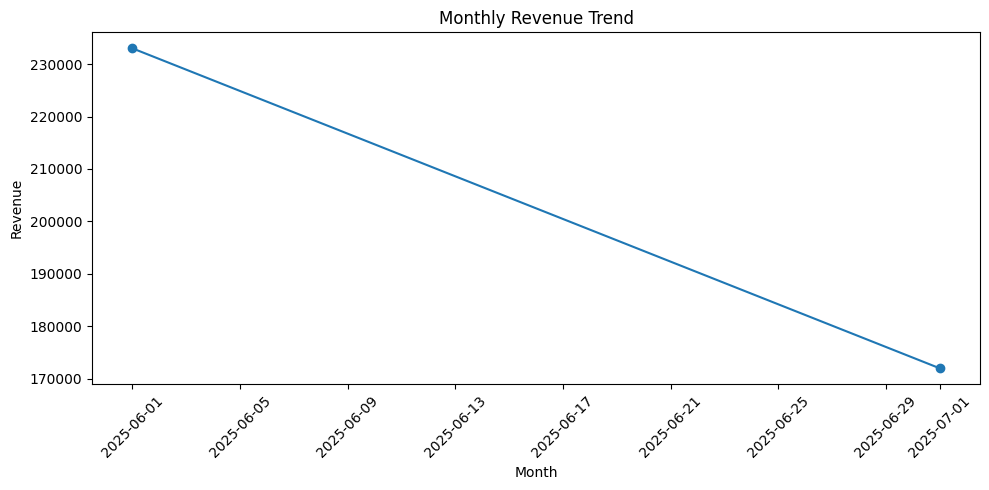

In [139]:
monthly_revenue["month"] = pd.to_datetime(
    monthly_revenue["month"]
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## **Category revenue chart**

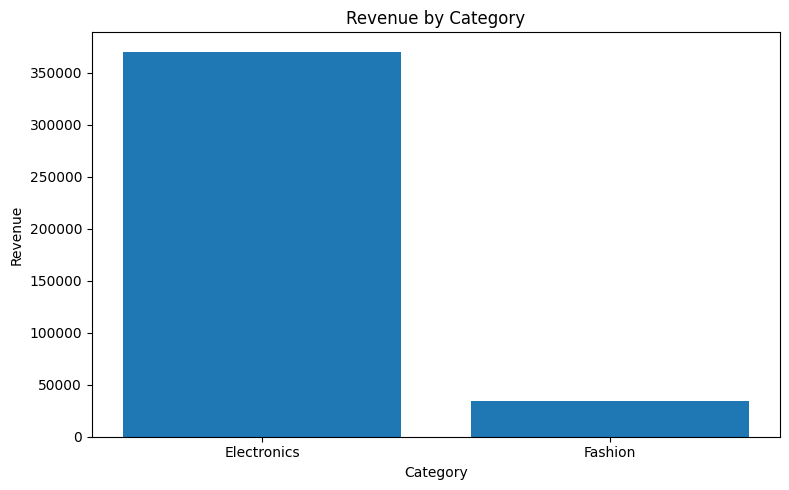

In [140]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_revenue["category"],
    category_revenue["revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [141]:
total_revenue = orders_clean["total_amount"].sum()
total_orders = len(orders_clean)
total_customers = len(customers_clean)

print("=" * 55)
print("CUSTOMER DATA ETL & ANALYTICS PIPELINE")
print("=" * 55)

print(f"Total Customers       : {total_customers}")
print(f"Total Valid Orders    : {total_orders}")
print(f"Total Revenue         : ₹{total_revenue:,.2f}")

print("\nTop Revenue Categories:")
print(category_revenue)

print("\nTop 5 Customers:")
print(top_customers.head(5))

print("\nPipeline Status:")
print("✓ Data Extraction")
print("✓ Data Cleaning")
print("✓ Data Validation")
print("✓ Data Transformation")
print("✓ Database Loading")
print("✓ SQL Analytics")
print("✓ Visualization")

CUSTOMER DATA ETL & ANALYTICS PIPELINE
Total Customers       : 15
Total Valid Orders    : 18
Total Revenue         : ₹405,000.00

Top Revenue Categories:
      category   revenue
0  Electronics  370400.0
1      Fashion   34600.0

Top 5 Customers:
   customer_id   name     city  total_spending
0            5  Rohan     Pune         69000.0
1           11  Arjun    Delhi         58000.0
2            1  Aarav    Delhi         55000.0
3           13  Varun  Chennai         52000.0
4            2  Priya   Mumbai         50000.0

Pipeline Status:
✓ Data Extraction
✓ Data Cleaning
✓ Data Validation
✓ Data Transformation
✓ Database Loading
✓ SQL Analytics
✓ Visualization


In [142]:
query = """
WITH customer_spending AS (

    SELECT
        c.customer_id,
        c.name,
        c.city,
        COALESCE(SUM(o.total_amount), 0) AS total_spending
    FROM customers c
    LEFT JOIN orders o
        ON c.customer_id = o.customer_id
    GROUP BY
        c.customer_id,
        c.name,
        c.city
)

SELECT
    customer_id,
    name,
    city,
    ROUND(total_spending, 2) AS total_spending,

    CASE
        WHEN total_spending >= 50000
            THEN 'High Value'

        WHEN total_spending >= 20000
            THEN 'Medium Value'

        ELSE 'Low Value'
    END AS customer_segment

FROM customer_spending
ORDER BY total_spending DESC;
"""

customer_segments = pd.read_sql_query(
    query,
    connection
)

customer_segments.head(10)

,customer_id,name,city,total_spending,customer_segment
0,5,Rohan,Pune,69000.0,High Value
1,11,Arjun,Delhi,58000.0,High Value
2,1,Aarav,Delhi,55000.0,High Value
3,13,Varun,Chennai,52000.0,High Value
4,2,Priya,Mumbai,50000.0,High Value
5,7,Aditya,Unknown,47500.0,Medium Value
6,3,Rahul,Bangalore,31000.0,Medium Value
7,9,Karan,Mumbai,14600.0,Low Value
8,15,Kabir,Mumbai,6000.0,Low Value
9,12,Simran,Pune,5400.0,Low Value


In [143]:
# Save processed datasets

customers_clean.to_csv(
    "customers_clean.csv",
    index=False
)

orders_clean.to_csv(
    "orders_clean.csv",
    index=False
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


#**3. Project Results**
The pipeline successfully:

Extracted customer and transaction data.
Identified duplicate and invalid records.
Cleaned and standardized the data.
Applied data-quality validation rules.
Calculated transaction-level revenue.
Loaded processed data into a relational SQLite database.
Executed SQL queries for business analytics.
Generated customer, product, category and monthly revenue insights.
Visualized revenue trends.
Key SQL Concepts Demonstrated
SELECT
WHERE
JOIN
GROUP BY
ORDER BY
LIMIT
Aggregate functions
CTE
CASE
Window functions

In [144]:
#connection.close()

#print("Database connection closed.")